# Peptide Detectability Prediction with a Bidirectional GRU

This notebook trains a deep learning model that predicts whether a peptide is **detectable**
by mass spectrometry directly from its amino-acid sequence. It is a binary classification
problem (`0 = not detectable`, `1 = detectable`).

## Architecture

The model is a stack of two **Bidirectional GRU** layers (an encoder → decoder style):

1. **Input** — one-hot encoded amino-acid sequences, padded to length 40 (alphabet size 21).
2. **Masking** — ignores the zero-padding positions.
3. **Bidirectional GRU (64 units, `return_sequences`)** — "encoder": reads the sequence in
   both directions and returns a representation at every position.
4. **Bidirectional GRU (64 units)** — "decoder": collapses the sequence into a single vector.
5. **Dense head** — Dropout → Flatten → Dense(128, ReLU) → Dropout → Dense(1, sigmoid).

## Data

Publicly available detectability datasets from the [Wilhelm Lab](https://huggingface.co/Wilhelmlab)
on Hugging Face:

| Dataset | Role |
|---|---|
| `detectability-proteometools` | Training / validation / internal test |
| `detectability-sinitcyn` | Training / validation / internal test |
| `detectability-wang` | **External** hold-out test set |

The `proteometools` and `sinitcyn` sets are pooled and re-split into train/val/test.
The `wang` set is kept completely separate as an independent generalization benchmark.

## 1. Imports and reproducibility

All random seeds are fixed so results are reproducible across runs.

In [1]:
import os
import random

import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

# --- Reproducibility: fix every source of randomness ---
SEED = 9999
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

sns.set_context("notebook")
sns.set_style("whitegrid")

## 2. Amino-acid vocabulary and sequence encoding

Each peptide is a string of amino-acid letters. We map every amino acid to an integer
(index `0` is reserved for padding / unknown), pad every sequence to a fixed length of 40,
and finally one-hot encode it into a `(40, 21)` matrix.

The 21-symbol alphabet = 20 standard amino acids + the `'0'` padding token.

In [2]:
# Amino-acid alphabet. '0' is the padding / unknown token at index 0.
AAlist = ['0', 'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L',
          'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
AAdict = {c: v for v, c in enumerate(AAlist)}


def transform_data(testin, testlabel, alphabet_size=0, max_length=0,
                   num_classes=0, AAdict=0):
    """Convert an iterable of peptide strings into a one-hot encoded tensor.

    Steps:
      1. Map each amino-acid character to its integer index (unknown -> 0).
      2. Pad / truncate every sequence to ``max_length`` (post-padding).
      3. One-hot encode to shape (n_sequences, max_length, alphabet_size).
    """
    encoded = [[AAdict.get(ch, 0) for ch in text] for text in testin]

    padded = tf.keras.utils.pad_sequences(
        encoded,
        maxlen=max_length,
        padding='post',
        truncating='post',
        value=0,
    )

    one_hot_encoder = tf.keras.layers.Lambda(
        lambda x: tf.one_hot(tf.cast(x, "int32"), depth=alphabet_size)
    )
    one_hot_data = one_hot_encoder(padded)
    return one_hot_data

## 3. Load the training datasets

We pull the ProteomeTools and Sinitcyn detectability datasets (all splits) straight from
Hugging Face. The original `Classes` column is multi-class; we collapse it into a binary
`blabels` column where `0` stays `0` (not detectable) and everything else becomes `1`
(detectable).

> **Note:** the `pd.read_parquet("hf://...")` calls download data over the network and
> require internet access plus the `huggingface_hub` and `pyarrow` packages.

In [3]:
splits = {
    'train': 'data/train-00000-of-00001.parquet',
    'val':   'data/val-00000-of-00001.parquet',
    'test':  'data/test-00000-of-00001.parquet',
}


def load_detectability(dataset, wanted_splits):
    """Load and concatenate the requested splits of a Wilhelmlab detectability dataset."""
    frames = []
    for split in wanted_splits:
        hf_data = pd.read_parquet(
            f"hf://datasets/Wilhelmlab/{dataset}/" + splits[split]
        )
        frames.append(pd.DataFrame({
            'seq': hf_data['Sequences'],
            'labels': hf_data['Classes'],
        }))
    df = pd.concat(frames)
    df['blabels'] = np.where(df.labels == 0, 0, 1)  # collapse to binary
    return df


proteome_dt = load_detectability('detectability-proteometools', ['train', 'test', 'val'])
sini_dt = load_detectability('detectability-sinitcyn', ['train', 'test', 'val'])

print('ProteomeTools:', proteome_dt.shape)
print('Sinitcyn:     ', sini_dt.shape)

ProteomeTools: (328832, 3)
Sinitcyn:      (246721, 3)


## 4. Load the external test set (Wang)

The Wang dataset is **never** used for training or model selection. It is our independent
benchmark for how well the model generalizes to data from a different source.

In [4]:
test_wang_dt = load_detectability('detectability-wang', ['test'])

test_wang_data = transform_data(
    testin=test_wang_dt.seq, testlabel=0,
    alphabet_size=21, max_length=40, num_classes=2, AAdict=AAdict,
)
test_wang_labels = test_wang_dt.blabels

print('Wang test data shape:', test_wang_data.shape)
print('Label distribution:  ', np.unique(test_wang_labels, return_counts=True))

Wang test data shape: (190955, 40, 21)
Label distribution:   (array([0, 1]), array([102758,  88197]))


## 5. Train / validation / test split

Pool ProteomeTools + Sinitcyn, then create a **stratified** 80/20 split into train and a
temporary set, and split that temporary set again into validation and internal test.
Stratification preserves the class balance in every split.

In [25]:
alldata = pd.concat([proteome_dt, sini_dt])

X_train, temp1, y_train, temp2 = train_test_split(
    alldata.seq, alldata.blabels,
    test_size=0.3, random_state=SEED, shuffle=True, stratify=alldata.blabels,
)
X_val, X_test, y_val, y_test = train_test_split(
    temp1, temp2,
    test_size=0.2, random_state=SEED, shuffle=True, stratify=temp2,
)

# One-hot encode each split
X_train2 = transform_data(X_train, 0, alphabet_size=21, max_length=40, num_classes=2, AAdict=AAdict)
X_val2   = transform_data(X_val,   0, alphabet_size=21, max_length=40, num_classes=2, AAdict=AAdict)
X_test2  = transform_data(X_test,  0, alphabet_size=21, max_length=40, num_classes=2, AAdict=AAdict)

print('Train:', X_train2.shape, np.unique(y_train, return_counts=True))
print('Val:  ', X_val2.shape,   np.unique(y_val,   return_counts=True))
print('Test: ', X_test2.shape,  np.unique(y_test,  return_counts=True))

Train: (402887, 40, 21) (array([0, 1]), array([103727, 299160]))
Val:   (138132, 40, 21) (array([0, 1]), array([ 35563, 102569]))
Test:  (34534, 40, 21) (array([0, 1]), array([ 8891, 25643]))


### Class weights

Detectability datasets are typically imbalanced. We compute balanced class weights so the
loss function pays proportionally more attention to the minority class during training.

In [15]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train,
)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

Class weights: {0: 1.9420637063031447, 1: 0.6733626599901724}


## 6. Build the Bidirectional GRU model

In [7]:
model = keras.models.Sequential([
    keras.layers.Input(shape=(40, 21)),
    keras.layers.Masking(mask_value=0),
    keras.layers.Bidirectional(                             # "encoder": returns sequence
        keras.layers.GRU(64, return_sequences=True,recurrent_initializer="glorot_uniform")),
    keras.layers.Bidirectional(                             # "decoder": collapses to a vector
        keras.layers.GRU(64, recurrent_initializer="glorot_uniform")),
    keras.layers.Dropout(0.5, seed=SEED),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(rate=0.5, seed=SEED),
    keras.layers.Dense(units=1, activation='sigmoid'),
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 40, 21)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 40, 128)        │        33,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,545 (486.50 KB)

 Trainable params: 124,545 (486.50 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Training callbacks

- **ReduceLROnPlateau** — halves the learning rate when validation loss stalls.
- **EarlyStopping** — stops training when validation loss stops improving (patience 5).
- **ModelCheckpoint** — saves the best weights (by validation accuracy) to disk.

In [8]:
lr_reduction = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', patience=3, verbose=1, factor=0.5, min_lr=1e-7,
)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', mode='min', patience=5, verbose=1,
)

# Weights are saved relative to the notebook so the repo stays portable.
model_save_path = 'peptide_alldata_model_weights_detectability.weights.h5'
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=model_save_path,
    monitor='val_accuracy', mode='max', verbose=1,
    save_best_only=True, save_weights_only=True,
)

## 8. Train the model

We keep the returned `history` object so we can plot the learning curves afterwards.

> **Tip:** Training is much faster on a GPU. The recurrent (GRU) layers are the
> bottleneck, and on CPU each epoch takes several minutes; on a CUDA-enabled GPU the
> same run is typically an order of magnitude faster. Verify a GPU is visible with
> `tf.config.list_physical_devices('GPU')` before training.

In [16]:
history = model.fit(
    X_train2, y_train,
    epochs=20,
    batch_size=524,
    validation_data=(X_val2, y_val),
    callbacks=[early_stopping, lr_reduction, model_checkpoint],
    class_weight=class_weights,
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7626 - loss: 0.5436
Epoch 1: val_accuracy improved from None to 0.81431, saving model to peptide_alldata_model_weights_detectability.weights.h5

Epoch 1: finished saving model to peptide_alldata_model_weights_detectability.weights.h5
57/57 ━━━━━━━━━━━━━━━━━━━━ 551s 10s/step - accuracy: 0.7724 - loss: 0.5330 - val_accuracy: 0.8143 - val_loss: 0.4714 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8007 - loss: 0.4999
Epoch 2: val_accuracy improved from 0.81431 to 0.82651, saving model to peptide_alldata_model_weights_detectability.weights.h5

Epoch 2: finished saving model to peptide_alldata_model_weights_detectability.weights.h5
57/57 ━━━━━━━━━━━━━━━━━━━━ 549s 10s/step - accuracy: 0.8076 - loss: 0.4949 - val_accuracy: 0.8265 - val_loss: 0.4584 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8261 - loss: 0.4707
Epoch 3: val_accuracy improved from 0.

## 9. Validation plots — learning curves

Train vs. validation **loss** and **accuracy** per epoch. Watch for the validation curve
diverging from the training curve, which signals over-fitting.

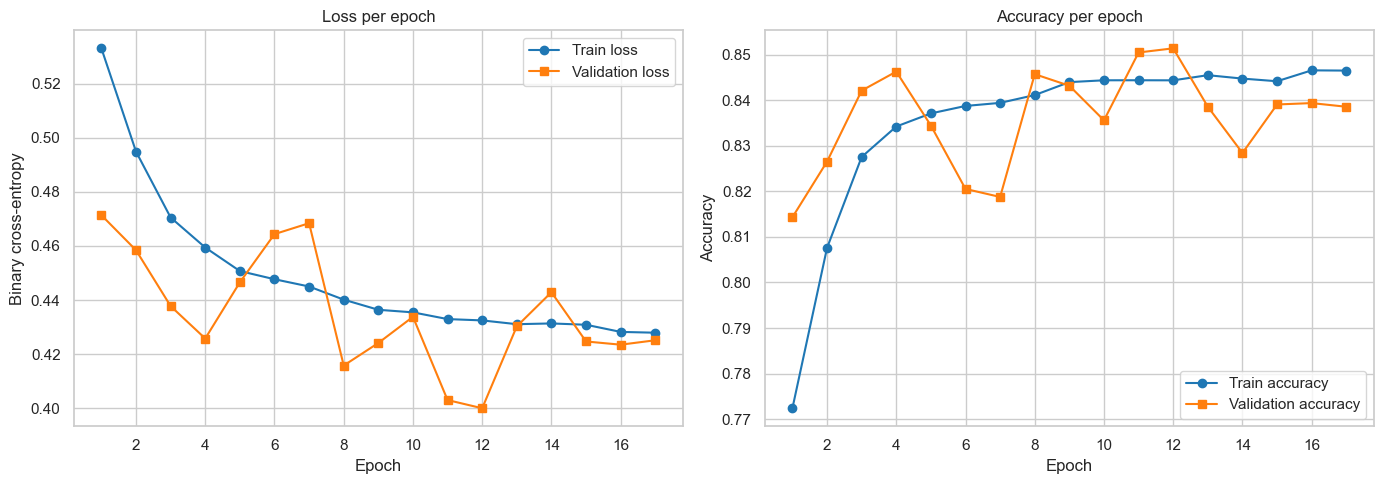

In [17]:
hist = history.history
epochs = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, hist['loss'], 'o-', label='Train loss')
axes[0].plot(epochs, hist['val_loss'], 's-', label='Validation loss')
axes[0].set_title('Loss per epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary cross-entropy')
axes[0].legend()

# Accuracy
axes[1].plot(epochs, hist['accuracy'], 'o-', label='Train accuracy')
axes[1].plot(epochs, hist['val_accuracy'], 's-', label='Validation accuracy')
axes[1].set_title('Accuracy per epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

### Held-out evaluation (internal val / test)

Quick sanity check of loss and accuracy on the validation and internal test splits.

In [18]:
val_loss, val_acc = model.evaluate(X_val2, y_val, verbose=0)
test_loss, test_acc = model.evaluate(X_test2, y_test, verbose=0)
print(f"Validation   -> loss: {val_loss:.4f}, accuracy: {val_acc:.4f}")
print(f"Internal test-> loss: {test_loss:.4f}, accuracy: {test_acc:.4f}")

Validation   -> loss: 0.4252, accuracy: 0.8385
Internal test-> loss: 0.4253, accuracy: 0.8376


## 10. External test set (Wang) — predictions

Now evaluate the trained model on the completely independent Wang dataset. Probabilities
above 0.5 are classified as detectable (`1`).

In [19]:
y_true = test_wang_dt.blabels.to_numpy()
y_proba = model.predict(test_wang_data).ravel()
y_pred = (y_proba > 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=['Not detectable', 'Detectable']))

5968/5968 ━━━━━━━━━━━━━━━━━━━━ 220s 37ms/step
                precision    recall  f1-score   support

Not detectable       0.83      0.51      0.64    102758
    Detectable       0.61      0.88      0.72     88197

      accuracy                           0.68    190955
     macro avg       0.72      0.70      0.68    190955
  weighted avg       0.73      0.68      0.67    190955



### Confusion matrix

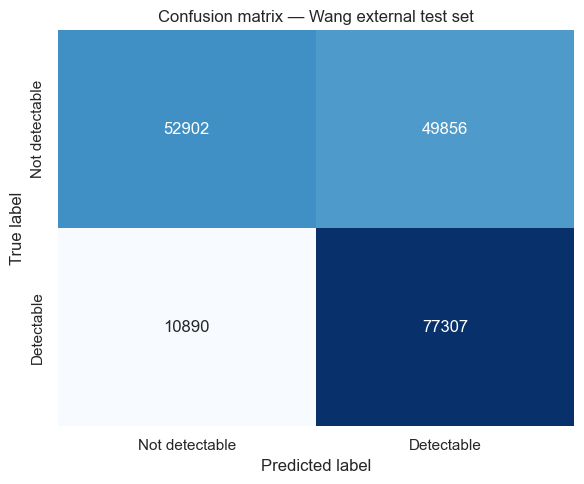

In [20]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Not detectable', 'Detectable'],
    yticklabels=['Not detectable', 'Detectable'], ax=ax,
)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion matrix — Wang external test set')
plt.tight_layout()
plt.savefig('confusion_matrix_wang.png', dpi=150, bbox_inches='tight')
plt.show()

### Derived clinical-style metrics

From the confusion matrix we compute false-positive rate, specificity and false-negative
rate — useful when the cost of a missed detection differs from a false alarm.

In [21]:
TN, FP, FN, TP = cm.ravel()

FPR = FP / (FP + TN)
specificity = TN / (TN + FP)
FNR = FN / (FN + TP)
sensitivity = TP / (TP + FN)  # recall of the positive class
precision = TP / (TP + FP)

print(f"True Negatives : {TN}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")
print(f"True Positives : {TP}")
print('-' * 30)
print(f"Sensitivity (recall): {sensitivity:.4f}")
print(f"Specificity         : {specificity:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"False Positive Rate : {FPR:.4f}")
print(f"False Negative Rate : {FNR:.4f}")

True Negatives : 52902
False Positives: 49856
False Negatives: 10890
True Positives : 77307
------------------------------
Sensitivity (recall): 0.8765
Specificity         : 0.5148
Precision           : 0.6079
False Positive Rate : 0.4852
False Negative Rate : 0.1235


### ROC and Precision–Recall curves

Threshold-independent views of performance. AUC summarizes ranking quality; average
precision summarizes the precision/recall trade-off (informative under class imbalance).

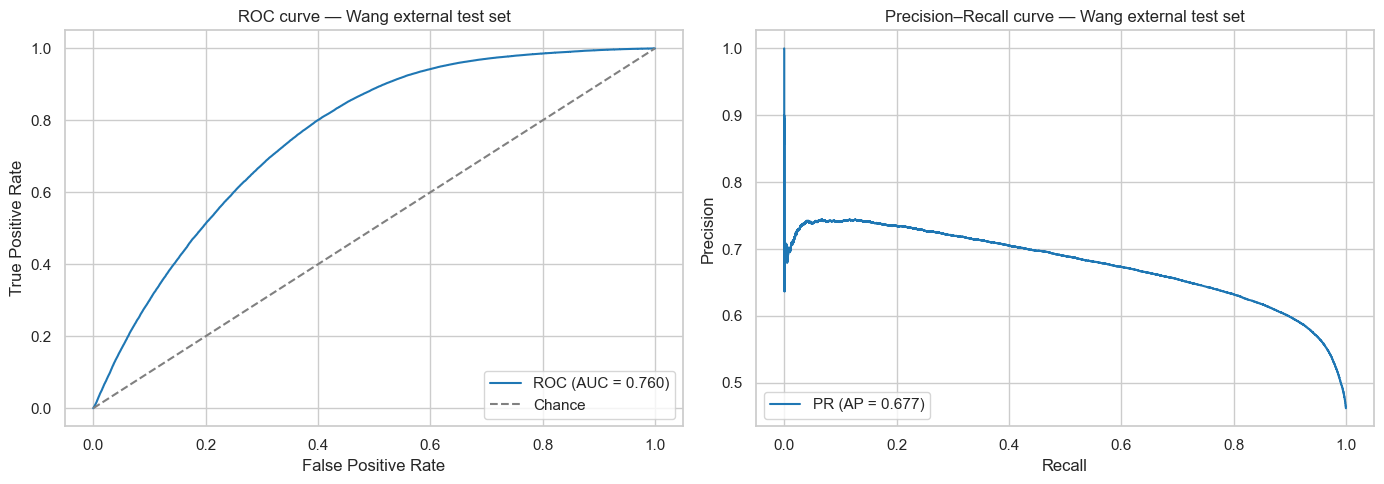

In [22]:
fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

prec, rec, _ = precision_recall_curve(y_true, y_proba)
ap = average_precision_score(y_true, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], '--', color='grey', label='Chance')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curve — Wang external test set')
axes[0].legend(loc='lower right')

# Precision-Recall
axes[1].plot(rec, prec, label=f'PR (AP = {ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall curve — Wang external test set')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig('roc_pr_curves_wang.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

This notebook loaded public peptide-detectability datasets, trained a stacked
Bidirectional GRU classifier with class balancing and early stopping, and evaluated it on an
independent external test set (Wang) using a confusion matrix, ROC/PR curves and
sensitivity/specificity-style metrics.

Best weights are saved to `peptide_alldata_model_weights_detectability` and all figures
are written to PNG files next to the notebook.